In [ ]:
from PIL import Image # Reading and manipulating images
import numpy as np # Math stuff
import matplotlib.pyplot as plt # Plot stuff
from matplotlib.patches import Rectangle

ModuleNotFoundError: No module named 'pandas'

In [2]:
box_fill = (42, 255, 128)
box_stroke = (255, 153, 153)

Text(0, 0.5, 'y')

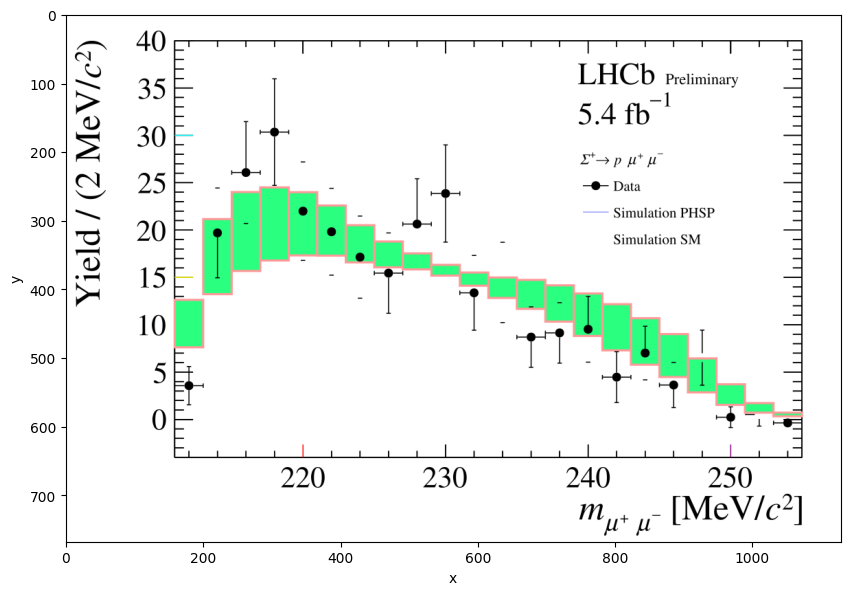

In [3]:
img = Image.open('in/smpred_Sigmapmumu.png')

plt.figure(figsize=(10,10))
plt.imshow(np.asarray(img))
plt.xlabel('x')
plt.ylabel('y')

In [4]:
# Corner coordinates are returned as (x, y), with x increasing rightward and y downward.
pixels = np.asarray(img.convert('RGB'))

# Allow for antialiased pixels.  This is a Euclidean RGB-distance tolerance.
colour_tolerance = 55
distance_to_fill = np.linalg.norm(pixels.astype(np.int16) - np.array(box_fill), axis=-1)
distance_to_stroke = np.linalg.norm(pixels.astype(np.int16) - np.array(box_stroke), axis=-1)
is_fill = distance_to_fill <= colour_tolerance
is_stroke = distance_to_stroke <= colour_tolerance

# Segment on the fill only: contiguous boxes may share a stroke, but their
# differently coloured stroke keeps their filled interiors disconnected.
box_pixels = is_fill

# Label 8-connected coloured regions without requiring an extra package.
height, width = box_pixels.shape
seen = np.zeros_like(box_pixels, dtype=bool)
boxes = []
for y, x in zip(*np.nonzero(box_pixels & ~seen)):
    if seen[y, x]:
        continue
    stack = [(y, x)]
    seen[y, x] = True
    xs, ys = [], []
    while stack:
        cy, cx = stack.pop()
        xs.append(cx)
        ys.append(cy)
        for ny in range(max(0, cy - 1), min(height, cy + 2)):
            for nx in range(max(0, cx - 1), min(width, cx + 2)):
                if box_pixels[ny, nx] and not seen[ny, nx]:
                    seen[ny, nx] = True
                    stack.append((ny, nx))

    # Ignore isolated pixels or tiny colour artifacts.
    if len(xs) >= 20:
        x0, x1 = int(min(xs)), int(max(xs))
        y0, y1 = int(min(ys)), int(max(ys))
        boxes.append({
            'top_left': (x0, y0),
            'top_right': (x1, y0),
            'bottom_right': (x1, y1),
            'bottom_left': (x0, y1),
        })

# Stable, visual reading order: top-to-bottom, then left-to-right.
boxes.sort(key=lambda b: (b['top_left'][1], b['top_left'][0]))
boxes


[{'top_left': (285, 254),
  'top_right': (322, 254),
  'bottom_right': (322, 356),
  'bottom_left': (285, 356)},
 {'top_left': (243, 261),
  'top_right': (280, 261),
  'bottom_right': (280, 371),
  'bottom_left': (243, 371)},
 {'top_left': (326, 261),
  'top_right': (363, 261),
  'bottom_right': (363, 348),
  'bottom_left': (326, 348)},
 {'top_left': (368, 280),
  'top_right': (405, 280),
  'bottom_right': (405, 349),
  'bottom_left': (368, 349)},
 {'top_left': (202, 300),
  'top_right': (239, 300),
  'bottom_right': (239, 405),
  'bottom_left': (202, 405)},
 {'top_left': (409, 309),
  'top_right': (446, 309),
  'bottom_right': (446, 358),
  'bottom_left': (409, 358)},
 {'top_left': (451, 333),
  'top_right': (488, 333),
  'bottom_right': (488, 366),
  'bottom_left': (451, 366)},
 {'top_left': (492, 350),
  'top_right': (529, 350),
  'bottom_right': (529, 369),
  'bottom_left': (492, 369)},
 {'top_left': (534, 367),
  'top_right': (571, 367),
  'bottom_right': (571, 378),
  'bottom_lef

In [5]:
def draw_boxes(boxes, ax=None):
    if ax is None:
        ax = plt.gca()
    for box in boxes:
        col = (1-box_stroke[0]/255, 1-box_stroke[1]/255, 1-box_stroke[2]/255)
        x0, y0 = box['top_left']
        x1, y1 = box['bottom_right']
        rect = Rectangle((x0, y0), x1 - x0, y1 - y0,
                         linewidth=2, edgecolor=col, facecolor='none')
        ax.add_patch(rect)

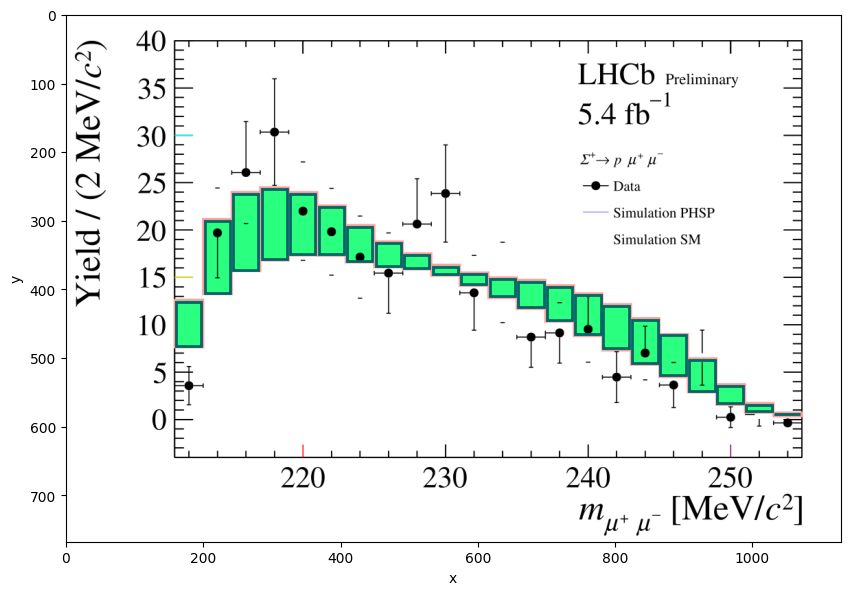

In [6]:
img = Image.open('in/smpred_Sigmapmumu.png')

plt.figure(figsize=(10,10))
plt.imshow(np.asarray(img))
plt.xlabel('x')
plt.ylabel('y')
draw_boxes(boxes)

In [7]:
color_markers = {'x1': (255, 0, 0), 'x2': (128, 0, 128), 'y1': (255, 255, 0), 'y2': (0, 255, 255)}
values_markers = {'x1': 220, 'x2': 250, 'y1': 15, 'y2': 30}

In [8]:
# Locate the centre of each coloured axis marker in bitmap coordinates.
marker_colour_tolerance = 55
pixels_i16 = pixels.astype(np.int16)
marker_pixels = {}
for name, colour in color_markers.items():
    distance = np.linalg.norm(pixels_i16 - np.array(colour), axis=-1)
    ys, xs = np.nonzero(distance <= marker_colour_tolerance)
    if len(xs) == 0:
        raise ValueError(f'No pixels found for marker {name!r}; increase the tolerance if needed.')
    marker_pixels[name] = (float(np.median(xs)), float(np.median(ys)))

# Linear calibrations.  The signs are determined by the marker positions,
# so the y calibration correctly handles image y increasing downward.
x1_px, _ = marker_pixels['x1']
x2_px, _ = marker_pixels['x2']
_, y1_px = marker_pixels['y1']
_, y2_px = marker_pixels['y2']
if x1_px == x2_px or y1_px == y2_px:
    raise ValueError('The two calibration markers for each axis must have different pixel positions.')

x_scale = (values_markers['x2'] - values_markers['x1']) / (x2_px - x1_px)
y_scale = (values_markers['y2'] - values_markers['y1']) / (y2_px - y1_px)

def pixel_to_plot(x_px, y_px):
    """Convert bitmap pixel coordinates (x, y) to plot coordinates."""
    x = values_markers['x1'] + (x_px - x1_px) * x_scale
    y = values_markers['y1'] + (y_px - y1_px) * y_scale
    return x, y

# The detected boxes expressed in plot coordinates.
plot_boxes = [
    {corner: pixel_to_plot(*pixel_point) for corner, pixel_point in box.items()}
    for box in boxes
]

print('Marker positions (pixels):', marker_pixels)
x_offset = values_markers['x1'] - x_scale * x1_px
y_offset = values_markers['y1'] - y_scale * y1_px
print(f'x = {x_scale:.8g} * pixel_x + {x_offset:.8g}')
print(f'y = {y_scale:.8g} * pixel_y + {y_offset:.8g}')
plot_boxes


Marker positions (pixels): {'x1': (345.0, 635.5), 'x2': (968.0, 635.5), 'y1': (171.5, 383.0), 'y2': (171.5, 176.0)}
x = 0.048154093 * pixel_x + 203.38684
y = -0.072463768 * pixel_y + 42.753623


[{'top_left': (217.1107544141252, 24.347826086956523),
  'top_right': (218.892455858748, 24.347826086956523),
  'bottom_right': (218.892455858748, 16.956521739130434),
  'bottom_left': (217.1107544141252, 16.956521739130434)},
 {'top_left': (215.08828250401285, 23.84057971014493),
  'top_right': (216.86998394863562, 23.84057971014493),
  'bottom_right': (216.86998394863562, 15.869565217391305),
  'bottom_left': (215.08828250401285, 15.869565217391305)},
 {'top_left': (219.08507223113963, 23.84057971014493),
  'top_right': (220.86677367576243, 23.84057971014493),
  'bottom_right': (220.86677367576243, 17.536231884057973),
  'bottom_left': (219.08507223113963, 17.536231884057973)},
 {'top_left': (221.107544141252, 22.46376811594203),
  'top_right': (222.8892455858748, 22.46376811594203),
  'bottom_right': (222.8892455858748, 17.46376811594203),
  'bottom_left': (221.107544141252, 17.46376811594203)},
 {'top_left': (213.1139646869984, 21.014492753623188),
  'top_right': (214.8956661316212

(-5.0, 40.0)

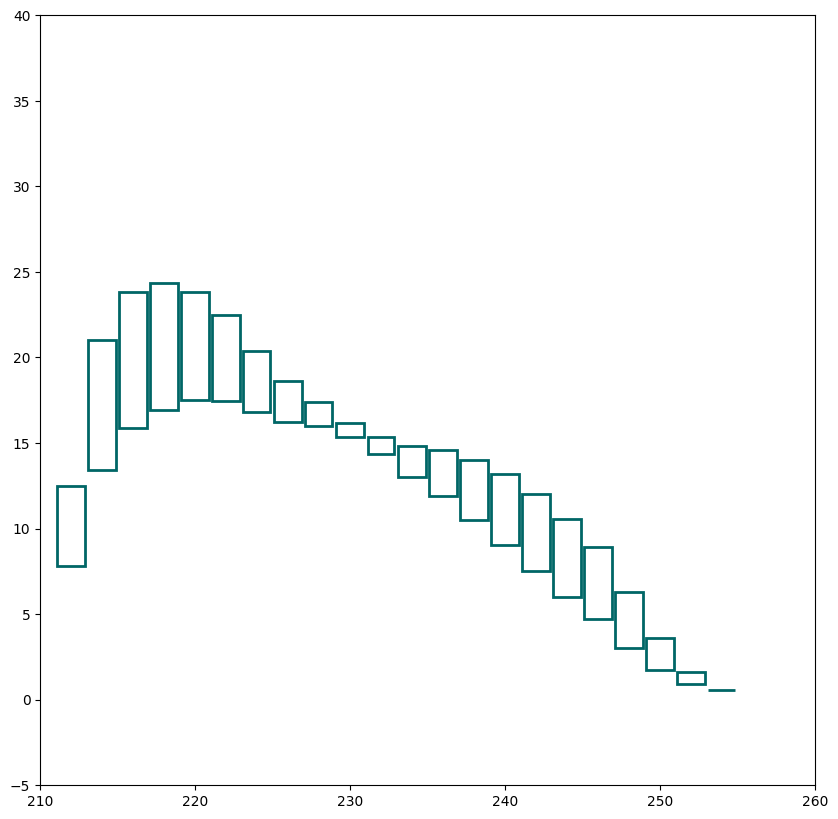

In [11]:
fig, ax = plt.subplots(figsize=(10,10))

draw_boxes(plot_boxes, ax=ax)
plt.xlim(210, 260)
plt.ylim(-5, 40)

In [14]:
with open('out/Sigmapmumu_smpred.csv', 'w') as f:
    f.write('mmumu,central,err\n')
    for b in plot_boxes:
        x0, y0 = b['top_left']
        x1, y1 = b['bottom_right']
        mmumu = (x0 + x1) / 2
        central = (y0 + y1) / 2
        err = (y0 - y1) / 2
        f.write(f'{mmumu},{central},{err}\n')